In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df= pd.read_csv("funnel_data.csv")
df.head()

,user_id,step,timestamp
0,1.0,visit,01-01-2024
1,1.0,product view,01-01-2024
2,1.0,add to cart,01-01-2024
3,1.0,purchase,01-01-2024
4,2.0,visit,01-01-2024


In [5]:
df.info()
df["step"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    7 non-null      float64
 1   step       7 non-null      object 
 2   timestamp  7 non-null      object 
dtypes: float64(1), object(2)
memory usage: 324.0+ bytes


step
product view    3
visit           2
add to cart     1
purchase        1
Name: count, dtype: int64

In [ ]:
#define funnel steps


In [7]:
funnel_steps = [
    "visit",
    "product_view",
    "add_to_cart",
    "purchase"
]

In [ ]:
# count users at each step


In [9]:
funnel_counts = []

for step in funnel_steps:
    users = df[df["step"] == step]["user_id"].nunique()
    funnel_counts.append(users)

funnel_counts

[2, 0, 0, 1]

In [ ]:
# calculate conversion rates


In [13]:
conversion_rates = []

for i in range(len(funnel_counts)):
    if i == 0:
        conversion_rates.append(100)
    elif funnel_counts[i-1] == 0:
        conversion_rates.append(0)
    else:
        rate = (funnel_counts[i] / funnel_counts[i-1]) * 100
        conversion_rates.append(round(rate, 2))

conversion_rates

[100, 0.0, 0, 0]

In [ ]:
# create funnel summary table


In [23]:
funnel_df = pd.DataFrame({
    "Step": funnel_steps,
    "Users": funnel_counts,
    "Conversion Rate (%)": conversion_rates
})

funnel_df

,Step,Users,Conversion Rate (%)
0,visit,2,100.0
1,product_view,0,0.0
2,add_to_cart,0,0.0
3,purchase,1,0.0


In [ ]:
#funnel visualization


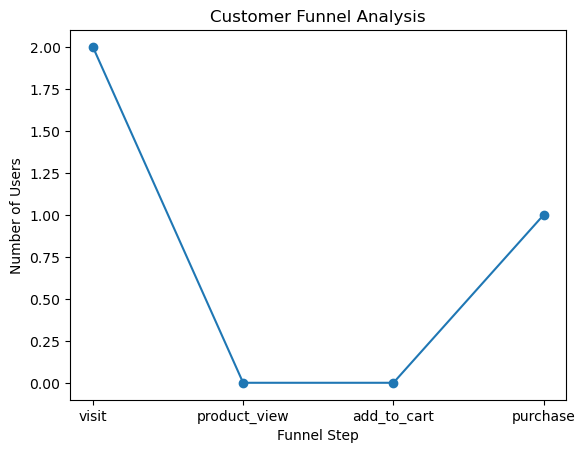

In [25]:
plt.figure()
plt.plot (funnel_df["Step"], funnel_df["Users"], marker="o")
plt.title("Customer Funnel Analysis")
plt.xlabel("Funnel Step")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
# drop off analysis


In [27]:
funnel_df["Drop-Off (%)"] = 100 - funnel_df["Conversion Rate (%)"]
funnel_df

,Step,Users,Conversion Rate (%),Drop-Off (%)
0,visit,2,100.0,0.0
1,product_view,0,0.0,100.0
2,add_to_cart,0,0.0,100.0
3,purchase,1,0.0,100.0
